In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("helper"))

from plot_utils import (
    np,
    pd,
    plt,
    save_figure,
    load_file,
    read_config_from_csv,
    list_runs,
    FIGURE_SIZE_HALF,
    LINE_STYLE,
    MARKER_STYLE,
    GRID_STYLE,
    THEORY_LINE_STYLE,
    slate_teal,
    navy,
)
from analysis import from_round_one, cpu_seconds_per_round_per_node

FIG_DIR = "../figures/evaluation/envelope"
os.makedirs(FIG_DIR, exist_ok=True)


def mean_memory_per_node(df):
    per_node_means = []

    for node, df_node in df.groupby("node"):
        memory_mb = pd.to_numeric(df_node[df_node.field == "memory_mb"].value, errors="coerce").dropna()
        per_node_means.append(float(memory_mb.mean()))

    return per_node_means


def steady_state_df(csv_path):
    return from_round_one(load_file(csv_path)), read_config_from_csv(csv_path)


def aggregate_by_param(base_dir, param_key, param_cast=float):
    cpu_by_param = {}
    memory_by_param = {}

    for name, path in list_runs(base_dir):
        config = read_config_from_csv(path)
        param_value = param_cast(config[param_key])
        n_rounds = int(config["n_rounds"])

        df = from_round_one(load_file(path))
        cpu_seconds = cpu_seconds_per_round_per_node(df, n_rounds)
        memory = mean_memory_per_node(df)

        if param_value not in cpu_by_param:
            cpu_by_param[param_value] = []
        cpu_by_param[param_value].append(float(np.mean(cpu_seconds)))

        if param_value not in memory_by_param:
            memory_by_param[param_value] = []
        memory_by_param[param_value].append(float(np.mean(memory)))

    return cpu_by_param, memory_by_param

In [2]:
metrics_path = "../metrics"

In [3]:
def per_run_aggregates(df):
    df = df[df.field.isin(["total_sent", "forwarded", "fragments_sent"])].copy()
    df["v"] = pd.to_numeric(df.value, errors="coerce")
    df["t"] = (df.timestamp - df.timestamp.min()).dt.total_seconds()

    ordered = df.sort_values("t")
    last = ordered.groupby(["node", "field"]).agg(v=("v", "last"), t_first=("t", "min"), t_last=("t", "max"))

    pivoted = last["v"].unstack("field")
    span = (last["t_last"] - last["t_first"]).groupby("node").max()

    pivoted["active"] = span
    pivoted["covers"] = pivoted["total_sent"] - pivoted["forwarded"] - pivoted["fragments_sent"]

    return pivoted

In [4]:
def per_run_scalars(csv_path):
    df, config = steady_state_df(csv_path)
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    current_round = df[df["field"] == "current_round"].dropna(subset=["value"])
    window_start = current_round["timestamp"].min()
    window_end = current_round["timestamp"].max() - pd.Timedelta(seconds=5)

    rtt = df[(df["field"] == "avg_rtt") & (df["timestamp"] >= window_start) & (df["timestamp"] <= window_end)].dropna(
        subset=["value"]
    )
    closed_loops = rtt[rtt["value"] > 0]["value"]
    avg_rtt_s = float(closed_loops.median())
    loop_frac = float(len(closed_loops) / len(rtt))

    sent = df[df["field"] == "total_mbytes_sent"].dropna(subset=["value"]).sort_values("timestamp")
    per_node = sent.groupby("node").agg(
        v0=("value", "first"),
        v1=("value", "last"),
        t0=("timestamp", "first"),
        t1=("timestamp", "last"),
    )
    mbytes_change = per_node["v1"] - per_node["v0"]
    elapsed_seconds = (per_node["t1"] - per_node["t0"]).dt.total_seconds()
    bw_mbps = float((mbytes_change / elapsed_seconds.replace(0, np.nan)).mean())

    return {
        "mu": config["mix_mu"],
        "k": config["max_hops"],
        "o": config["mix_outbox_size"],
        "avg_rtt_s": avg_rtt_s,
        "loop_frac": loop_frac,
        "bw_mbps": bw_mbps,
    }

In [5]:
def load_sweep(folder):
    runs = list_runs(os.path.join(metrics_path, folder))

    rows = []
    for name, path in runs:
        seed = int(name.rsplit("_seed_", 1)[1])

        scalars = per_run_scalars(path)
        scalars["seed"] = seed
        scalars["run"] = name
        rows.append(scalars)

    return pd.DataFrame(rows).sort_values(["mu", "k", "o", "seed"]).reset_index(drop=True)


mu_df = load_sweep("b1_mu_sweep")
k_df = load_sweep("b1_k_sweep")
o_df = load_sweep("b1_o_sweep")

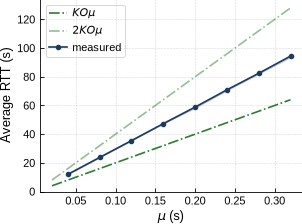

In [6]:
fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
ax.grid(**GRID_STYLE)

mus = np.linspace(0.02, 0.32, 200)
ax.plot(mus, 200 * mus, label=r"$KO\mu$", **THEORY_LINE_STYLE)
ax.plot(mus, 400 * mus, label=r"$2KO\mu$", alpha=0.5, **THEORY_LINE_STYLE)

agg = (
    mu_df.dropna(subset=["avg_rtt_s"])
    .groupby("mu")["avg_rtt_s"]
    .agg(["mean", "min", "max"])
    .reset_index()
    .sort_values("mu")
)
ax.fill_between(agg["mu"], agg["min"], agg["max"], color=navy, alpha=0.2)
ax.plot(agg["mu"], agg["mean"], marker="o", color=navy, label="measured", markersize=3, **LINE_STYLE)

ax.set_xlabel(r"$\mu$ (s)")
ax.set_ylabel("Average RTT (s)")
ax.set_ylim(bottom=0)
ax.legend(loc="best")

fig.tight_layout()
save_figure(fig, f"{FIG_DIR}/mixnet_rtt_vs_mu.pdf")
plt.show()

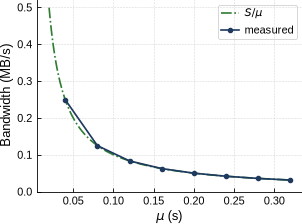

In [7]:
fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
ax.grid(**GRID_STYLE)

mus = np.linspace(0.02, 0.32, 200)
ax.plot(mus, (10469 / mus) / (2**20), label=r"$S/\mu$", **THEORY_LINE_STYLE)

agg = mu_df.groupby("mu")["bw_mbps"].agg(["mean", "min", "max"]).reset_index()
ax.fill_between(agg["mu"], agg["min"], agg["max"], color=navy, alpha=0.2)
ax.plot(agg["mu"], agg["mean"], marker="o", color=navy, label="measured", markersize=3, **LINE_STYLE)

ax.set_xlabel(r"$\mu$ (s)")
ax.set_ylabel("Bandwidth (MB/s)")
ax.set_ylim(bottom=0)
ax.legend(loc="best")
fig.tight_layout()
save_figure(fig, f"{FIG_DIR}/mixnet_bandwidth_vs_mu.pdf")
plt.show()

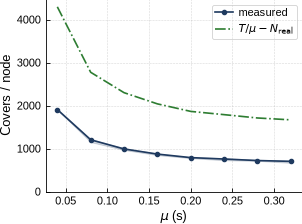

In [8]:
cov_rows = []
for name, path in list_runs(os.path.join(metrics_path, "b1_mu_sweep")):
    config = read_config_from_csv(path)
    seed = int(name.rsplit("_seed_", 1)[1])

    df = load_file(path)
    per_node = per_run_aggregates(df)

    cov_rows.append(
        (
            config["mix_mu"],
            seed,
            float(per_node["covers"].mean()),
            float(per_node["fragments_sent"].mean()),
            float(per_node["active"].mean()),
        )
    )

df_cov = pd.DataFrame(cov_rows, columns=["mu", "seed", "covers_per_node", "real_per_node", "active_s"])
cov_agg = (
    df_cov.groupby("mu")
    .agg(
        mean=("covers_per_node", "mean"),
        min=("covers_per_node", "min"),
        max=("covers_per_node", "max"),
        active=("active_s", "mean"),
        real=("real_per_node", "mean"),
    )
    .reset_index()
    .sort_values("mu")
)
cov_agg["analytical"] = cov_agg["active"] / cov_agg["mu"] - cov_agg["real"]

fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)

ax.fill_between(cov_agg["mu"], cov_agg["min"], cov_agg["max"], color=navy, alpha=0.2)
ax.plot(cov_agg["mu"], cov_agg["mean"], marker="o", color=navy, markersize=3, label="measured", **LINE_STYLE)
ax.plot(cov_agg["mu"], cov_agg["analytical"], label=r"$T/\mu - N_\text{real}$", **THEORY_LINE_STYLE)
ax.set_xlabel(r"$\mu$ (s)")
ax.set_ylabel("Covers / node")

ax.grid(**GRID_STYLE)
ax.set_ylim(bottom=0)
ax.legend(loc="upper right", framealpha=0.9)
fig.tight_layout()

save_figure(fig, f"{FIG_DIR}/covers_per_node_vs_mu.pdf")
plt.show()

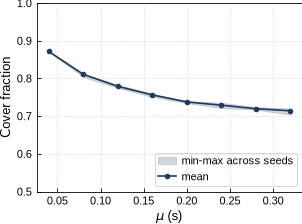

In [9]:
mu_frac_rows = []
for name, path in list_runs(os.path.join(metrics_path, "b1_mu_sweep")):
    config = read_config_from_csv(path)

    df = load_file(path)
    per_node = per_run_aggregates(df)

    cover_fraction = (per_node["covers"] / (per_node["covers"] + per_node["fragments_sent"])).mean()
    mu_frac_rows.append((config["mix_mu"], float(cover_fraction)))

df_mu_frac = pd.DataFrame(mu_frac_rows, columns=["mu", "frac"])
agg_mu_frac = (
    df_mu_frac.groupby("mu")
    .agg(mean=("frac", "mean"), lo=("frac", "min"), hi=("frac", "max"))
    .reset_index()
    .sort_values("mu")
)

fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
ax.fill_between(
    agg_mu_frac["mu"], agg_mu_frac["lo"], agg_mu_frac["hi"], color=navy, alpha=0.2, label="min-max across seeds"
)
ax.plot(agg_mu_frac["mu"], agg_mu_frac["mean"], marker="o", color=navy, markersize=3, label="mean", **LINE_STYLE)
ax.set_xlabel(r"$\mu$ (s)")
ax.set_ylabel("Cover fraction")
ax.set_ylim(0.5, 1.0)
ax.grid(**GRID_STYLE)

ax.legend(loc="lower right", framealpha=0.9)
fig.tight_layout()
save_figure(fig, f"{FIG_DIR}/cover_fraction_vs_mu.pdf")
plt.show()

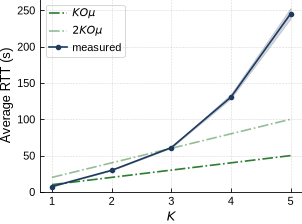

In [10]:
fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
ax.grid(**GRID_STYLE)

ks = np.linspace(1, 5, 100)
ax.plot(ks, 10 * ks, label=r"$KO\mu$", **THEORY_LINE_STYLE)
ax.plot(ks, 20 * ks, label=r"$2KO\mu$", alpha=0.5, **THEORY_LINE_STYLE)

agg = (
    k_df.dropna(subset=["avg_rtt_s"])
    .groupby("k")["avg_rtt_s"]
    .agg(["mean", "min", "max"])
    .reset_index()
    .sort_values("k")
)
ax.fill_between(agg["k"], agg["min"], agg["max"], color=navy, alpha=0.2)
ax.plot(agg["k"], agg["mean"], marker="o", color=navy, label="measured", markersize=3, **LINE_STYLE)

ax.set_xlabel(r"$K$")
ax.set_ylabel("Average RTT (s)")
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_ylim(bottom=0)
ax.legend(loc="best")

fig.tight_layout()
save_figure(fig, f"{FIG_DIR}/mixnet_rtt_vs_k.pdf")
plt.show()

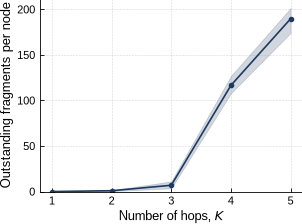

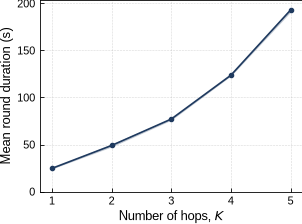

In [11]:
def round_time_per_run(df):
    rounds = df[df.field == "current_round"].copy()
    rounds["v"] = pd.to_numeric(rounds.value, errors="coerce")
    rounds = rounds.dropna(subset=["v"]).sort_values("timestamp")

    per_node_means = []
    for node, g in rounds.groupby("node"):
        entry = g.groupby("v")["timestamp"].min().sort_index()
        gaps = entry.diff().dropna().dt.total_seconds()
        per_node_means.append(float(gaps.mean()))

    return float(np.mean(per_node_means))


backlog_rows = []
for name, path in list_runs("../metrics/b1_k_sweep"):
    config = read_config_from_csv(path)
    k = int(config["max_hops"])

    df, _ = steady_state_df(path)
    unacked = pd.to_numeric(
        df[df.field == "unacked_msg"].sort_values("timestamp").groupby("node")["value"].last(), errors="coerce"
    ).dropna()

    backlog_rows.append((k, float(unacked.mean()), round_time_per_run(df)))

backlog_df = pd.DataFrame(backlog_rows, columns=["k", "unacked", "round_t"])
backlog_agg = (
    backlog_df.groupby("k")
    .agg(
        unacked_mean=("unacked", "mean"),
        unacked_min=("unacked", "min"),
        unacked_max=("unacked", "max"),
        rt_mean=("round_t", "mean"),
        rt_min=("round_t", "min"),
        rt_max=("round_t", "max"),
    )
    .reset_index()
    .sort_values("k")
)
k_values = backlog_agg["k"].tolist()

fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
ax.fill_between(k_values, backlog_agg["unacked_min"], backlog_agg["unacked_max"], color=navy, alpha=0.2)
ax.plot(k_values, backlog_agg["unacked_mean"], color=navy, marker="o", markersize=3, **LINE_STYLE)
ax.set_xlabel("Number of hops, $K$")
ax.set_ylabel("Outstanding fragments per node")
ax.set_xticks(k_values)
ax.set_ylim(bottom=0)
ax.grid(**GRID_STYLE)
fig.tight_layout()
save_figure(fig, f"{FIG_DIR}/outstanding_fragments_vs_k.pdf")
plt.show()

fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
ax.fill_between(k_values, backlog_agg["rt_min"], backlog_agg["rt_max"], color=navy, alpha=0.2)
ax.plot(k_values, backlog_agg["rt_mean"], color=navy, marker="o", markersize=3, **LINE_STYLE)

ax.set_xlabel("Number of hops, $K$")
ax.set_ylabel("Mean round duration (s)")
ax.set_xticks(k_values)
ax.set_ylim(bottom=0)
ax.grid(**GRID_STYLE)

fig.tight_layout()

save_figure(fig, f"{FIG_DIR}/round_time_vs_k.pdf")
plt.show()

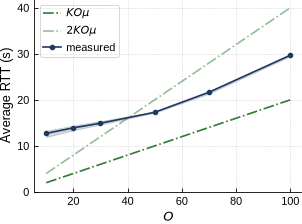

In [12]:
fig, ax = plt.subplots(figsize=FIGURE_SIZE_HALF)
ax.grid(**GRID_STYLE)

os_grid = np.linspace(10, 100, 200)
ax.plot(os_grid, 0.2 * os_grid, label=r"$KO\mu$", **THEORY_LINE_STYLE)
ax.plot(os_grid, 0.4 * os_grid, label=r"$2KO\mu$", alpha=0.5, **THEORY_LINE_STYLE)

agg = (
    o_df.dropna(subset=["avg_rtt_s"])
    .groupby("o")["avg_rtt_s"]
    .agg(["mean", "min", "max"])
    .reset_index()
    .sort_values("o")
)
ax.fill_between(agg["o"], agg["min"], agg["max"], color=navy, alpha=0.2)
ax.plot(agg["o"], agg["mean"], marker="o", color=navy, label="measured", markersize=3, **LINE_STYLE)

ax.set_xlabel(r"$O$")
ax.set_ylabel("Average RTT (s)")
ax.set_ylim(bottom=0)
ax.legend(loc="best")
fig.tight_layout()
save_figure(fig, f"{FIG_DIR}/mixnet_rtt_vs_o.pdf")
plt.show()

In [13]:
MU_DIR = "../metrics/b1_mu_sweep"
K_DIR = "../metrics/b1_k_sweep"
O_DIR = "../metrics/b1_o_sweep"

CPU_LABEL = "Mean CPU time per round (s)"
MEM_LABEL = "Mean memory per node (MB)"


def band(ax, x_values, series, color, linestyle="-"):
    ys_mean = [float(np.mean(series[x])) for x in x_values]
    ys_lo = [float(np.min(series[x])) for x in x_values]
    ys_hi = [float(np.max(series[x])) for x in x_values]

    ax.plot(x_values, ys_mean, color=color, linewidth=1.2, linestyle=linestyle, **MARKER_STYLE)
    ax.fill_between(x_values, ys_lo, ys_hi, color=color, alpha=0.2, linewidth=0)


def plot_single_sweep(cpu_at, mem_at, x_label, cpu_out_path, mem_out_path, x_int_ticks=False):
    x_values = sorted(cpu_at)
    mem_ys = [float(np.mean(mem_at[x])) for x in x_values]

    fig_cpu, ax_cpu = plt.subplots(figsize=FIGURE_SIZE_HALF)
    band(ax_cpu, x_values, cpu_at, slate_teal)
    ax_cpu.set_xlabel(x_label)
    ax_cpu.set_ylabel(CPU_LABEL)
    ax_cpu.grid(**GRID_STYLE)

    if x_int_ticks:
        ax_cpu.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    plt.tight_layout()
    save_figure(fig_cpu, cpu_out_path)
    plt.show()

    fig_mem, ax_mem = plt.subplots(figsize=FIGURE_SIZE_HALF)
    band(ax_mem, x_values, mem_at, slate_teal)
    ax_mem.set_xlabel(x_label)
    ax_mem.set_ylabel(MEM_LABEL)
    ax_mem.set_ylim(min(mem_ys) - 20, max(mem_ys) + 20)

    ax_mem.grid(**GRID_STYLE)

    if x_int_ticks:
        ax_mem.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    plt.tight_layout()

    save_figure(fig_mem, mem_out_path)
    plt.show()

    return {x: float(np.mean(cpu_at[x])) for x in x_values}, {x: float(np.mean(mem_at[x])) for x in x_values}

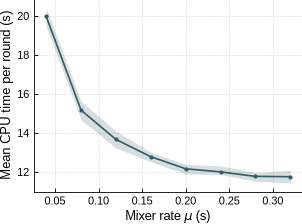

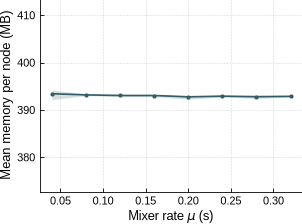

In [14]:
cpu_at, mem_at = aggregate_by_param(MU_DIR, "mix_mu")
cpu_mu, mem_mu = plot_single_sweep(
    cpu_at,
    mem_at,
    x_label=r"Mixer rate $\mu$ (s)",
    cpu_out_path=f"{FIG_DIR}/cpu_vs_mu.pdf",
    mem_out_path=f"{FIG_DIR}/memory_vs_mu.pdf",
)

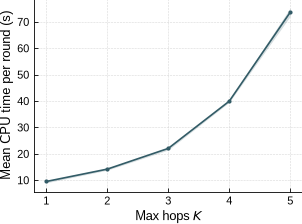

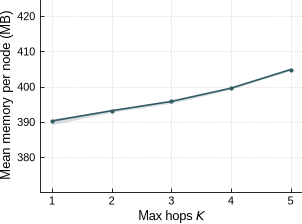

In [15]:
cpu_at, mem_at = aggregate_by_param(K_DIR, "max_hops", int)
cpu_k, mem_k = plot_single_sweep(
    cpu_at,
    mem_at,
    x_label=r"Max hops $K$",
    cpu_out_path=f"{FIG_DIR}/cpu_vs_k.pdf",
    mem_out_path=f"{FIG_DIR}/memory_vs_k.pdf",
    x_int_ticks=True,
)

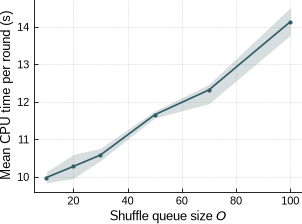

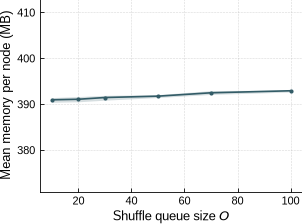

In [16]:
cpu_at, mem_at = aggregate_by_param(O_DIR, "mix_outbox_size", int)
cpu_o, mem_o = plot_single_sweep(
    cpu_at,
    mem_at,
    x_label=r"Shuffle queue size $O$",
    cpu_out_path=f"{FIG_DIR}/cpu_vs_o.pdf",
    mem_out_path=f"{FIG_DIR}/memory_vs_o.pdf",
)